<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/MODEL2_BayesianCNN_MJCtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Modeling with Pyro and PyTorch

This notebook gives two detailed examples of Bayesian neural modeling using **Pyro** and **PyTorch**:

1. **Bayesian linear regression** for a simple regression problem.
2. **Bayesian convolutional neural network (CNN)** for MNIST image classification.

The goal is to show how Pyro changes the usual neural-network workflow. In standard PyTorch, the weights are fixed trainable parameters. In Pyro, we can make selected weights, biases, or noise terms into **random variables** with prior distributions. We then use data to infer an approximate posterior distribution over those random variables.

The notebook uses **stochastic variational inference (SVI)**. SVI approximates the posterior distribution with a simpler variational distribution called a **guide**, and learns the guide parameters by minimizing the negative evidence lower bound, often abbreviated as the negative ELBO.

> Note: The MNIST Bayesian CNN is intentionally small and uses a subset of MNIST by default. Fully Bayesian CNNs are computationally expensive because we infer distributions over many weights.

## 0. Installation Notes

Run the following cell if Pyro is not installed in your environment.

If you are using Google Colab, uncomment and run the install line. If you are using a local environment, install these packages from a terminal or environment manager.

In [1]:
# Uncomment this line if Pyro is not installed.
%pip install pyro-ppl torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 20.2 MB/s eta 0:00:00


## 1. Imports and Reproducibility

We will use:

- `torch` for tensors, neural network layers, and optimization.
- `pyro` for probabilistic models and variational inference.
- `torchvision` for MNIST.
- `matplotlib` for visualization.

In [2]:
import math
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam

try:
    from torchvision import datasets, transforms
    TORCHVISION_AVAILABLE = True
except Exception as e:
    TORCHVISION_AVAILABLE = False
    print("torchvision could not be imported:", e)

In [4]:
def set_seed(seed=0):
    """Set random seeds for reproducible examples."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
pyro.set_rng_seed(42)
pyro.clear_param_store()

# Use a GPU if one is available. Otherwise use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


# Part I: Bayesian Linear Regression

## 2. Mathematical Model

Suppose we observe pairs $(x_i, y_i)$. A standard linear regression model assumes

$$
y_i = wx_i + b + \epsilon_i,
$$

where $w$ is the slope, $b$ is the intercept, and $\epsilon_i$ is random noise.

In a **Bayesian** model, we place prior distributions on unknown quantities. For example:

$$
w \sim \mathcal{N}(0, 10),
$$

$$
b \sim \mathcal{N}(0, 10),
$$

$$
\sigma \sim \text{LogNormal}(0, 1),
$$

$$
y_i \mid x_i, w, b, \sigma \sim \mathcal{N}(wx_i + b, \sigma).
$$

After observing data, the posterior distribution tells us which values of \(w\), \(b\), and \($\sigma$\) are plausible.

# Part II: Bayesian CNN for MNIST

## 9. CNN Classification Setup

MNIST contains grayscale images of handwritten digits. Each image has shape \(1 \times 28 \times 28\), and the label is one of 10 classes.

A conventional CNN learns fixed convolutional filters. A Bayesian CNN places probability distributions over the filters and dense-layer weights.

In this example, we use a very small CNN:

1. Bayesian convolution layer from 1 channel to 4 channels.
2. ReLU and max pooling.
3. Bayesian convolution layer from 4 channels to 8 channels.
4. ReLU and max pooling.
5. Bayesian fully connected hidden layer.
6. Bayesian output layer for 10 digit classes.

Because the CNN weights are random variables, prediction is performed by sampling multiple networks from the posterior and averaging their predicted probabilities.

## 10. Load MNIST

The next cell downloads MNIST using `torchvision`. To keep the Bayesian CNN example fast, we use small subsets by default.

You can increase `train_subset_size`, `test_subset_size`, `num_epochs`, or `max_batches_per_epoch` if you want a more serious experiment.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cpu


In [7]:
from re import X
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

ECG_data_1K = np.load('ECG_waveforms_2K.npy')
# ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

labels = Echo_5K['shd_moderate_or_greater_flag']


#initial definitions
negative = labels==0
positive = labels==1
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)


(1000, 12, 2500)
(1000,)


In [8]:
#train & test
X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long)

ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))
print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))


torch.Size([32, 12, 2500])
Time-series training samples: 800
Time-series test samples: 200


## 12. Define a Bayesian CNN with PyroModule and PyroSample

`PyroModule` allows a PyTorch module to contain random parameters.

`PyroSample` replaces a deterministic parameter, such as a weight tensor, with a prior distribution. During inference, Pyro learns an approximate posterior over these random tensors.

The model below uses:

- Normal priors for convolution and dense weights.
- Categorical likelihood for class labels.
- Logits returned by the CNN.

The final likelihood is

$$
y_i \mid x_i, \theta \sim \text{Categorical}(\text{logits}=f_\theta(x_i)),
$$

where $\theta$ represents all Bayesian weights and biases.

In [25]:
class BayesianSmallCNN(PyroModule):
    def __init__(self, prior_scale=0.10):
        super().__init__()

        self.conv1 = PyroModule[nn.Conv1d](12, 8, kernel_size=5, padding=2)
        self.conv1.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([8, 12, 5]).to_event(3)
        )
        self.conv1.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([8]).to_event(1)
        )

        self.conv2 = PyroModule[nn.Conv1d](8, 12, kernel_size=5, padding=2)
        self.conv2.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([12, 8, 5]).to_event(3)
        )
        self.conv2.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([12]).to_event(1)
        )

        flattened_dim = 12 * 625

        self.fc1 = PyroModule[nn.Linear](flattened_dim, 32)
        self.fc1.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([32, flattened_dim]).to_event(2)
        )
        self.fc1.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([32]).to_event(1)
        )

        self.fc2 = PyroModule[nn.Linear](32, 2)
        self.fc2.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([2, 32]).to_event(2)
        )
        self.fc2.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([2]).to_event(1)
        )

    def forward(self, x, y=None, dataset_size=None):
        batch_size = x.shape[0]

        x = torch.tanh(self.conv1(x))
        x = F.max_pool1d(x, kernel_size=2)

        x = torch.tanh(self.conv2(x))
        x = F.max_pool1d(x, kernel_size=2)

        x = torch.flatten(x, start_dim=1)
        x = torch.tanh(self.fc1(x))
        logits = self.fc2(x)

        if y is not None:
            if dataset_size is not None:
                scale = dataset_size / batch_size
            else:
                scale = 1.0

            with pyro.plate("data", batch_size):
                with pyro.poutine.scale(scale=scale):
                    pyro.sample("obs", dist.Categorical(logits=logits), obs=y)

        return logits

## 13. Create the Guide and SVI Object

We again use `AutoDiagonalNormal`. For a Bayesian CNN, this means Pyro creates a diagonal Normal variational posterior over all Bayesian weights and biases.

This is not the only possible guide, but it is a clear starting point for teaching and experimentation.

In [26]:
pyro.clear_param_store()
set_seed(72)

bcnn = BayesianSmallCNN(prior_scale=1.0).to(device)
bcnn_guide = AutoDiagonalNormal(bcnn)

bcnn_optimizer = Adam({"lr": 1e-3,"betas": (0.9, 0.999)})
bcnn_svi = SVI(
    model=bcnn,
    guide=bcnn_guide,
    optim=bcnn_optimizer,
    loss=Trace_ELBO(),
)

## 14. Training and Evaluation Utilities

The training loop is similar to ordinary PyTorch, except the optimization step is `svi.step(images, labels)` rather than `loss.backward()` followed by `optimizer.step()`.

For prediction, we sample several networks from the approximate posterior and average their softmax probabilities.

In [27]:
def train_one_epoch_svi(svi, data_loader, device, dataset_size, max_batches=None):
    total_loss = 0.0
    total_examples = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        loss = svi.step(x, y, dataset_size)
        total_loss += loss
        total_examples += x.shape[0]

    return total_loss / max(1, total_examples)

@torch.no_grad()
def predict_proba_bayesian(model, guide, x, num_samples=250):
    """Average class probabilities over posterior samples of the network."""
    predictive = Predictive(
        model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("_RETURN",),
    )
    out = predictive(x, None)

    # Shape is usually [num_samples, batch_size, num_classes].
    logits_samples = out["_RETURN"]
    probs_samples = torch.softmax(logits_samples, dim=-1)
    mean_probs = probs_samples.mean(dim=0)
    return mean_probs


@torch.no_grad()
def evaluate_bayesian_classifier(model, guide, data_loader, device, num_samples=2500, max_batches=None):
    """Evaluate posterior-averaged classification accuracy."""
    correct = 0
    total = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)
        mean_probs = predict_proba_bayesian(model, guide, x, num_samples=num_samples)
        preds = mean_probs.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()

    return correct / max(1, total)

## 15. Train the Bayesian CNN

This cell uses conservative defaults so it can run on a laptop. For better performance, try increasing:

- `train_subset_size`
- `num_epochs`
- `max_batches_per_epoch`
- `num_prediction_samples`

Fully Bayesian CNNs are much slower than deterministic CNNs because each prediction can require many posterior samples.

Epoch  1/50 | avg negative ELBO per example = 13945.20 | approx test accuracy = 0.555
Epoch  2/50 | avg negative ELBO per example = 13767.30 | approx test accuracy = 0.540
Epoch  3/50 | avg negative ELBO per example = 13592.62 | approx test accuracy = 0.560
Epoch  4/50 | avg negative ELBO per example = 13416.37 | approx test accuracy = 0.580
Epoch  5/50 | avg negative ELBO per example = 13241.77 | approx test accuracy = 0.550
Epoch  6/50 | avg negative ELBO per example = 13071.65 | approx test accuracy = 0.600
Epoch  7/50 | avg negative ELBO per example = 12898.68 | approx test accuracy = 0.600
Epoch  8/50 | avg negative ELBO per example = 12720.64 | approx test accuracy = 0.535
Epoch  9/50 | avg negative ELBO per example = 12545.40 | approx test accuracy = 0.580
Epoch 10/50 | avg negative ELBO per example = 12371.35 | approx test accuracy = 0.570
Epoch 11/50 | avg negative ELBO per example = 12199.44 | approx test accuracy = 0.555
Epoch 12/50 | avg negative ELBO per example = 12026.84

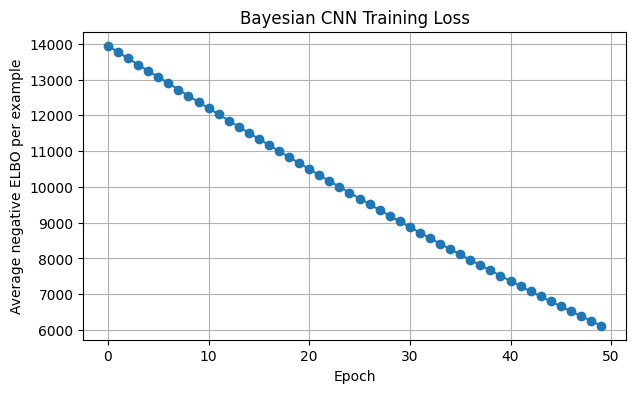

In [28]:
num_epochs = 50
max_batches_per_epoch = None
num_prediction_samples = 10

bcnn_losses = []

for epoch in range(num_epochs):
    avg_loss = train_one_epoch_svi(
    bcnn_svi,
    ts_train_loader,
    device,
    dataset_size = train_size,
    max_batches=max_batches_per_epoch,
)
    bcnn_losses.append(avg_loss)

    test_acc = evaluate_bayesian_classifier(
        bcnn,
        bcnn_guide,
        ts_test_loader,
        device,
        num_samples=num_prediction_samples,
        max_batches=5,
    )

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"avg negative ELBO per example = {avg_loss:.2f} | "
        f"approx test accuracy = {test_acc:.3f}"
    )

plt.figure(figsize=(7, 4))
plt.plot(bcnn_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average negative ELBO per example")
plt.title("Bayesian CNN Training Loss")
plt.grid(True)
plt.show()

## 16. Visualize Bayesian CNN Predictions

The predicted class is obtained by averaging softmax probabilities over posterior samples.

The maximum averaged probability gives a simple uncertainty summary:

- High value: the posterior ensemble mostly agrees.
- Low value: the posterior ensemble is less confident.

TypeError: Invalid shape (2500,) for image data

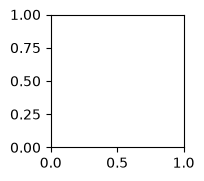

In [ ]:
images, labels = next(iter(ts_test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    mean_probs = predict_proba_bayesian(
        bcnn,
        bcnn_guide,
        images[:12],
        num_samples=30,
    )
    pred_labels = mean_probs.argmax(dim=-1)
    confidences = mean_probs.max(dim=-1).values

plt.figure(figsize=(12, 4))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(images[i].detach().cpu().numpy(), aspect="auto", cmap="gray")
    plt.title(
        f"true={labels[i].item()}\n"
        f"pred={pred_labels[i].item()}\n"
        f"conf={confidences[i].item():.2f}"
    )
    plt.axis("off")
plt.suptitle("Bayesian CNN Posterior-Averaged Predictions")
plt.tight_layout()
plt.show()

## 17. Class Probability Bar Plot for One Image

A Bayesian classifier gives a distribution over model weights. After averaging over posterior samples, we get posterior-averaged class probabilities.

In [ ]:
example_index = 10
probs = mean_probs[example_index].detach().cpu().numpy()

plt.figure(figsize=(7, 4))
plt.bar(np.arange(10), probs)
plt.xticks(np.arange(10))
plt.xlabel("Digit class")
plt.ylabel("Posterior-averaged probability")
plt.title(f"Predicted Probabilities for One MNIST Image, true label = {labels[example_index].item()}")
plt.grid(True, axis="y")
plt.show()